# Hate Speech Detection using LSTM

In [4]:
# importing libraries
import pandas as pd
import spacy
import numpy as np
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
#from keras.regularizers import l2
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('labeled_data.csv')

In [7]:
df.shape

(24783, 7)

- 0 - hate speech
- 1 - offensive language
- 2 - neither

In [8]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [9]:
# 1. DELETING UNWANTED COLUMNS
df.drop(columns = ['Unnamed: 0',	'count',	'hate_speech',	'offensive_language',	'neither'],
        inplace = True)

In [10]:
df.head()

,class,tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [11]:
# 2. CHECKING FOR NULL VALUES
df.isna().sum()

class    0
tweet    0
dtype: int64

In [12]:
df['tweet'].iloc[0]

"!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out..."

In [13]:
df['tweet'].iloc[100]

'"@ClicquotSuave: LMAOOOOOOOOOOO this nigga @Krillz_Nuh_Care http://t.co/AAnpSUjmYI" &lt;bitch want likes for some depressing shit..foh'

In [14]:
df['tweet'].iloc[1000]

'&#128514;&#128514;&#128514;&#128514;&#128514;&#128514;&#128514;"@betysweetcocker: That pussy is just....&#128561; imma assume she just had a baby like..the day before"'

In [15]:
# 3. REPLACING SYMBOLS AND NUMBERS FROM TEXT
df['processed_tweet'] = df['tweet'].str.replace(r'[^a-zA-Z]', ' ', regex = True)

In [16]:
df.head()

,class,tweet,processed_tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RT mayasolovely As a woman you shouldn t...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RT mleew boy dats cold tyga dwn ba...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RT UrKindOfBrand Dawg RT sbaby...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RT C G Anderson viva based she lo...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RT ShenikaRoberts The shit you...


In [17]:
df['processed_tweet'].iloc[0]

'    RT  mayasolovely  As a woman you shouldn t complain about cleaning up your house   amp  as a man you should always take the trash out   '

In [18]:
df['processed_tweet'].iloc[1000]

'                                                                 betysweetcocker  That pussy is just              imma assume she just had a baby like  the day before '

In [19]:
# 4. REPLACING MULTIPLE WHITESPACE CHARACTERS WITH SINGLE ONE
df['processed_tweet_2'] = df['processed_tweet'].str.replace(r'[\s]+', ' ', regex = True)

In [20]:
df['processed_tweet_2'].iloc[0]

' RT mayasolovely As a woman you shouldn t complain about cleaning up your house amp as a man you should always take the trash out '

In [21]:
df['processed_tweet_2'].iloc[1000]

' betysweetcocker That pussy is just imma assume she just had a baby like the day before '

In [22]:
df.head()

,class,tweet,processed_tweet,processed_tweet_2
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RT mayasolovely As a woman you shouldn t...,RT mayasolovely As a woman you shouldn t comp...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RT mleew boy dats cold tyga dwn ba...,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RT UrKindOfBrand Dawg RT sbaby...,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RT C G Anderson viva based she lo...,RT C G Anderson viva based she look like a tr...
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RT ShenikaRoberts The shit you...,RT ShenikaRoberts The shit you hear about me ...


In [23]:
df.drop(columns = ['tweet', 'processed_tweet'], inplace = True)

In [24]:
df.head()

,class,processed_tweet_2
0,2,RT mayasolovely As a woman you shouldn t comp...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,RT C G Anderson viva based she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...


In [71]:
# # 5. REPLACING THE TARGET VALUES
# df['class'].replace({0 : 'hate', 1 : 'offensive', 2 : 'neither'}, inplace = True)

In [25]:
df.head()

,class,processed_tweet_2
0,2,RT mayasolovely As a woman you shouldn t comp...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...
3,1,RT C G Anderson viva based she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...


In [27]:
# load out spacy modeule
nlp = spacy.load('en_core_web_sm')

In [28]:
# 6. LEMMATIZATION
def lemmatization(text):
  doc = nlp(text)
  lemmaList = [word.lemma_ for word in doc]
  return ' '.join(lemmaList)

df['lemma_tweet'] = df['processed_tweet_2'].apply(lemmatization)

In [29]:
df.head()

,class,processed_tweet_2,lemma_tweet
0,2,RT mayasolovely As a woman you shouldn t comp...,RT mayasolovely as a woman you shouldn t com...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad for cuffi...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...,RT UrKindOfBrand Dawg RT sbaby life you ever...
3,1,RT C G Anderson viva based she look like a tr...,RT C G Anderson viva base she look like a tr...
4,1,RT ShenikaRoberts The shit you hear about me ...,RT ShenikaRoberts the shit you hear about I ...


In [30]:
df['processed_tweet_2'].iloc[67]

' Allyhaaaaa Lemmie eat a Oreo amp do these dishes One oreo Lol'

In [31]:
df['lemma_tweet'].iloc[67]

'  Allyhaaaaa Lemmie eat a Oreo amp do these dish one oreo lol'

In [32]:
# 7. REMOVING STOPWORDS
def remove_stopwords(text):
  doc = nlp(text)
  no_stopwords_list = [word.text for word in doc if not word.is_stop]
  return ' '.join(no_stopwords_list)

df['final_tweet'] = df['lemma_tweet'].apply(remove_stopwords)

In [33]:
df.head()

,class,processed_tweet_2,lemma_tweet,final_tweet
0,2,RT mayasolovely As a woman you shouldn t comp...,RT mayasolovely as a woman you shouldn t com...,RT mayasolovely woman shouldn t complain cl...
1,1,RT mleew boy dats cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad for cuffi...,RT mleew boy dat cold tyga dwn bad cuffin d...
2,1,RT UrKindOfBrand Dawg RT sbaby life You ever ...,RT UrKindOfBrand Dawg RT sbaby life you ever...,RT UrKindOfBrand Dawg RT sbaby life fuck bi...
3,1,RT C G Anderson viva based she look like a tr...,RT C G Anderson viva base she look like a tr...,RT C G Anderson viva base look like tranny
4,1,RT ShenikaRoberts The shit you hear about me ...,RT ShenikaRoberts the shit you hear about I ...,RT ShenikaRoberts shit hear true faker bitc...


In [34]:
df['lemma_tweet'].iloc[67]

'  Allyhaaaaa Lemmie eat a Oreo amp do these dish one oreo lol'

In [35]:
df['final_tweet'].iloc[67]

'   Allyhaaaaa Lemmie eat Oreo amp dish oreo lol'

In [36]:
# 8. ONE - HOT REPRESENTATION

vocab_size = 10000
one_hot_representation = [one_hot(words, vocab_size) for words in df['final_tweet']]

In [37]:
df['final_tweet'].iloc[0]

'   RT mayasolovely woman shouldn t complain clean house amp man trash'

In [38]:
one_hot_representation[0]

[3599, 4109, 5122, 6659, 5975, 285, 1337, 431, 2150, 4625, 766]

In [39]:
# 9. PADDING AND EMBEDDING

sentence_length = 20
embedded_tweet = pad_sequences(one_hot_representation, padding='pre', maxlen = sentence_length)

In [40]:
embedded_tweet[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0, 3599, 4109,
       5122, 6659, 5975,  285, 1337,  431, 2150, 4625,  766])

In [41]:
# 10. DIVIDING THE DATASET
X = np.array(embedded_tweet)
y = np.array(df['class'])

In [42]:
smote = SMOTE(sampling_strategy='minority')
X, y = smote.fit_resample(X, y)

In [43]:
# 11. TRAIN - TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [46]:
# 12. CREATING MODEL

dimension = 50

model = keras.Sequential([
    #embedding layer
    keras.layers.Embedding(vocab_size, dimension, input_length = sentence_length),
    # LSTM layer
    keras.layers.LSTM(100,return_sequences=True),
    keras.layers.LSTM(50, return_sequences=True),
    keras.layers.LSTM(50),
    #output layer
    keras.layers.Dense(3, activation = 'softmax')
])

#compilation
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

In [47]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Get the embedding of the first row
embedding = model.layers[0](X_train[0:1])

print(embedding.numpy()[0])

[[ 0.08347893 -0.03496302  0.05748567 -0.08382316  0.02734222 -0.11498485
   0.01213804  0.1888674  -0.01522699 -0.09403589  0.13003808  0.00715914
   0.07067732 -0.21593606 -0.05740983 -0.09314747  0.06736995  0.00549831
   0.22037916 -0.01942482 -0.02599066  0.14477427  0.10478524  0.1433454
  -0.11532795 -0.15037777 -0.00061481  0.01436361 -0.0718638   0.05158414
   0.17380413  0.01489562  0.10792801  0.0497922   0.20702922 -0.02888104
   0.07568453  0.07341028  0.12427083 -0.04701995  0.00111371  0.06288721
  -0.01117025  0.07556418  0.06212348 -0.04264276 -0.01040604 -0.07032225
   0.04538254 -0.06043822]
 [ 0.08347893 -0.03496302  0.05748567 -0.08382316  0.02734222 -0.11498485
   0.01213804  0.1888674  -0.01522699 -0.09403589  0.13003808  0.00715914
   0.07067732 -0.21593606 -0.05740983 -0.09314747  0.06736995  0.00549831
   0.22037916 -0.01942482 -0.02599066  0.14477427  0.10478524  0.1433454
  -0.11532795 -0.15037777 -0.00061481  0.01436361 -0.0718638   0.05158414
   0.17380413

In [48]:
model.fit(X_train, y_train, epochs = 10, batch_size=32)

Epoch 1/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - accuracy: 0.8709 - loss: 0.3385
Epoch 2/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.9427 - loss: 0.1736
Epoch 3/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.9597 - loss: 0.1274
Epoch 4/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.9700 - loss: 0.0980
Epoch 5/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - accuracy: 0.9763 - loss: 0.0777
Epoch 6/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9810 - loss: 0.0592
Epoch 7/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.9861 - loss: 0.0427
Epoch 8/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.9895 - loss: 0.0302
Epoch 9/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.9928 - loss: 0.0214
Epoch 10/10
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9942 - loss: 0.0178


In [49]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Model Accuracy : {accuracy * 100}')

266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8987 - loss: 0.5939
Model Accuracy : 89.86955285072327


In [50]:
pred = np.argmax(model.predict(X_test), axis = -1)

266/266 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


In [51]:
y_test[:5]

array([1, 1, 0, 1, 2], dtype=int64)

In [52]:
pred[:5]

array([1, 1, 0, 1, 2], dtype=int64)

In [53]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      3812
           1       0.92      0.92      0.92      3807
           2       0.75      0.76      0.75       890

    accuracy                           0.90      8509
   macro avg       0.86      0.86      0.86      8509
weighted avg       0.90      0.90      0.90      8509



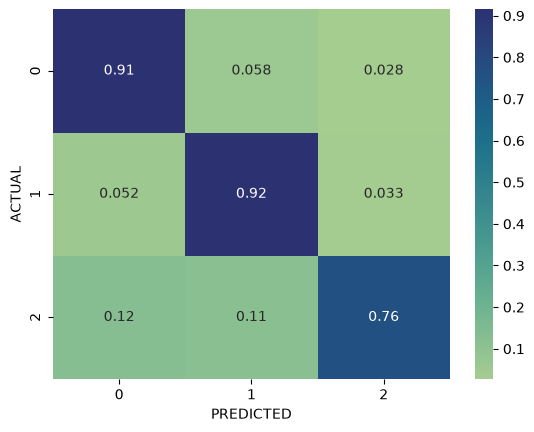

In [54]:
cf = confusion_matrix(y_test, pred, normalize = 'true')
sns.heatmap(cf, annot = True, cmap = 'crest')
plt.xlabel('PREDICTED'),
plt.ylabel('ACTUAL');

In [73]:
# Give your own sentence
# new_sentence = "You are an idiot"
# new_sentence = "I really like this person"
# new_sentence = "Shut up, you fool."
new_sentence = "you mofo."


# 1. Same preprocessing: remove non-English characters
new_sentence = new_sentence.replace(
    r'[^a-zA-Z]',
    ' '
)

# Better using regex:
import re
new_sentence = re.sub(r'[^a-zA-Z]', ' ', new_sentence)

# 2. Convert to lowercase
new_sentence = new_sentence.lower()

# 3. Lemmatization
doc = nlp(new_sentence)

lemma_words = [word.lemma_ for word in doc]

# 4. Remove stopwords
final_words = [
    word.text
    for word in nlp(" ".join(lemma_words))
    if not word.is_stop
]

final_sentence = " ".join(final_words)

print("Processed sentence:", final_sentence)

# 5. Convert words to integer IDs
sentence_encoded = one_hot(final_sentence, 10000)

print("Encoded:", sentence_encoded)

# 6. Padding to 20 words
sentence_padded = pad_sequences(
    [sentence_encoded],
    padding='pre',
    maxlen=20
)

print("Padded shape:", sentence_padded.shape)

# 7. Prediction
prediction = model.predict(sentence_padded)

print("Raw prediction:", prediction)

# 8. Get class with highest probability
predicted_class = np.argmax(prediction, axis=-1)[0]

print("Predicted class:", predicted_class)

Processed sentence: mofo
Encoded: [4721]
Padded shape: (1, 20)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Raw prediction: [[9.9985695e-01 9.5544674e-05 4.7496844e-05]]
Predicted class: 0


In [74]:
class_names = {
    0: "Hate Speech",
    1: "Offensive Language",
    2: "Neither"
}

print("Prediction:", class_names[predicted_class])

Prediction: Hate Speech
